Quantum ml fault detection

In [43]:
!pip install pennylane

In [44]:
from google.colab import files
uploaded = files.upload()

Saving sg_raw_data.csv to sg_raw_data (2).csv


In [45]:
import pandas as pd

data = pd.read_csv("sg_raw_data.csv")
print(data.head())

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab     stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347  unstable  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957    stable  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471  unstable  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871  unstable  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860  unstable  


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop("stabf", axis=1).values   # features
y = data["stabf"].values               # target (stable/unstable)

# Convert labels to numbers
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Quantum layer

In [47]:
import pennylane as qml
from pennylane import numpy as np

n_qubits = 6
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

Hybrid model

In [48]:
import torch
import torch.nn as nn

weight_shapes = {"weights": (3, n_qubits, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 8)
        self.fc_mid= nn.Linear(8, n_qubits)
        self.q_layer = qlayer
        self.fc2 = nn.Linear(n_qubits, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc_mid(x)
        x = self.q_layer(x)
        x = self.fc2(x)
        return x

model = HybridModel(X.shape[1])

Training

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Convert data to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Store losses
losses = []

# Training loop
epochs = 100

for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    # Store loss
    losses.append(loss.item())

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# ===== AFTER TRAINING ===== #

# Predictions (Train)
train_preds = torch.argmax(model(X_train_tensor), axis=1).detach().numpy()

# Predictions (Test)
test_outputs = model(X_test_tensor)
test_preds = torch.argmax(test_outputs, axis=1).detach().numpy()

# Accuracy
print("\nFinal Results:")
print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy:", accuracy_score(y_test, test_preds))

Epoch 0, Loss: 1.0549960136413574
Epoch 10, Loss: 0.9872909188270569
Epoch 20, Loss: 0.9282328486442566
Epoch 30, Loss: 0.8488481640815735
Epoch 40, Loss: 0.7438137531280518
Epoch 50, Loss: 0.6218224167823792
Epoch 60, Loss: 0.4861661195755005
Epoch 70, Loss: 0.35699462890625
Epoch 80, Loss: 0.2670692503452301
Epoch 90, Loss: 0.20693038403987885

Final Results:
Train Accuracy: 0.991125
Test Accuracy: 0.988


Plot Loss Curve

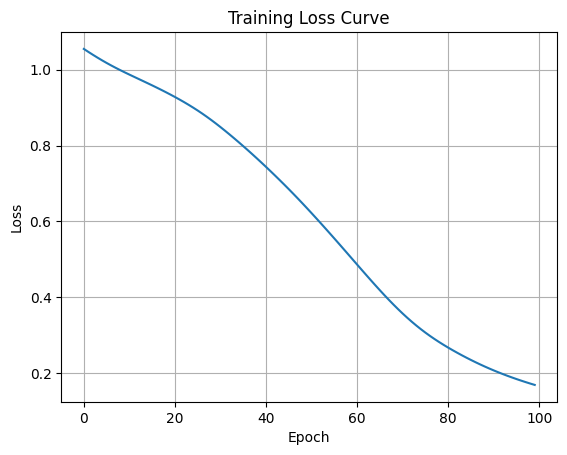

In [57]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()


Accuracy

In [58]:
from sklearn.metrics import accuracy_score

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

outputs = model(X_test_tensor)
preds = torch.argmax(outputs, axis=1).numpy()

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.988


Confusion Matrix

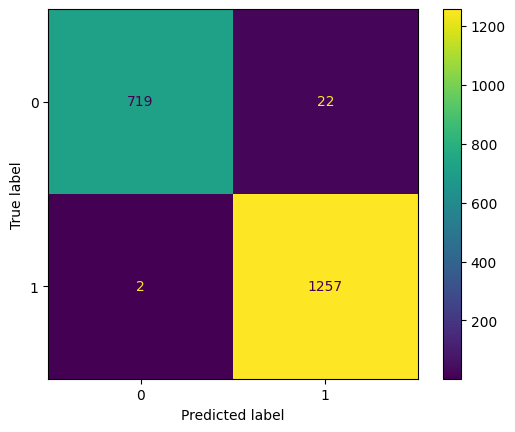

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Compare with classical model

In [60]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

preds_classical = clf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Classical Accuracy:", accuracy_score(y_test, preds_classical))

Classical Accuracy: 1.0


overfitting check

In [61]:
print("Train Accuracy:", accuracy_score(y_train, torch.argmax(model(X_train_tensor), axis=1)))
print("Test Accuracy:", accuracy_score(y_test, preds))

Train Accuracy: 0.991125
Test Accuracy: 0.988


In [62]:
torch.save(model.state_dict(), "quantum_model.pth")